In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("stealthtechnologies/rock-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 213M/213M [00:01<00:00, 147MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/stealthtechnologies/rock-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/stealthtechnologies/rock-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/stealthtechnologies/rock-classification/versions/1):
['Rock Data']


In [ ]:
import os

# Update path to match 'Rock Data' directory
rock_data_path = os.path.join(path, 'Rock Data')

# List subdirectories in Rock Data (usually class labels)
if os.path.exists(rock_data_path):
    print(f"Classes in dataset: {os.listdir(rock_data_path)}")
else:
    print(f"Directory not found: {rock_data_path}")

Classes in dataset: ['train', 'valid', 'test', 'README.dataset.txt', 'README.roboflow.txt']



--- Sample Images from Dataset (/root/.cache/kagglehub/datasets/stealthtechnologies/rock-classification/versions/1/Rock Data) ---
Found 4212 images. Displaying 6 samples:


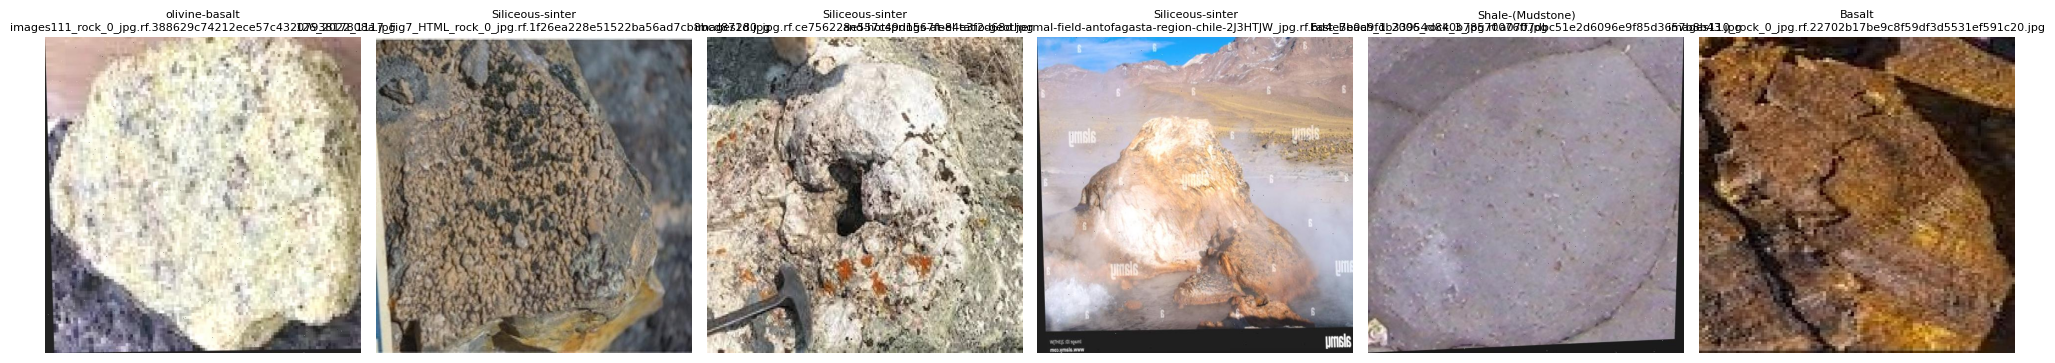

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} samples:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent directory) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the defined Rock Data path
rock_data_path = os.path.join(path, 'Rock Data')
print(f"\n--- Sample Images from Dataset ({rock_data_path}) ---")
display_sample_images(rock_data_path)

In [ ]:
import torch

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda
Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# Define paths
train_dir = os.path.join(rock_data_path, 'train')
val_dir = os.path.join(rock_data_path, 'valid')

# Data augmentation and normalization
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, data_transforms['val'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False)
}

# Initialize ResNet18
model = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(image_datasets['train'].classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
num_epochs = 10

for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())
        print(f'Epoch {epoch}/{num_epochs-1} {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


Epoch 0/9 train Loss: 1.7753 Acc: 0.3751
Epoch 0/9 val Loss: 1.5534 Acc: 0.4330
Epoch 1/9 train Loss: 1.5314 Acc: 0.4700
Epoch 1/9 val Loss: 2.1650 Acc: 0.3875
Epoch 2/9 train Loss: 1.3672 Acc: 0.5270
Epoch 2/9 val Loss: 1.4016 Acc: 0.5356
Epoch 3/9 train Loss: 1.3078 Acc: 0.5533
Epoch 3/9 val Loss: 1.2864 Acc: 0.5385
Epoch 4/9 train Loss: 1.2340 Acc: 0.5747
Epoch 4/9 val Loss: 1.2494 Acc: 0.5954
Epoch 5/9 train Loss: 1.1339 Acc: 0.6062
Epoch 5/9 val Loss: 1.5266 Acc: 0.5014
Epoch 6/9 train Loss: 1.0736 Acc: 0.6143
Epoch 6/9 val Loss: 1.6855 Acc: 0.4644
Epoch 7/9 train Loss: 1.0266 Acc: 0.6520
Epoch 7/9 val Loss: 1.5611 Acc: 0.4986
Epoch 8/9 train Loss: 0.9842 Acc: 0.6580
Epoch 8/9 val Loss: 2.8028 Acc: 0.4473
Epoch 9/9 train Loss: 0.9535 Acc: 0.6737
Epoch 9/9 val Loss: 1.6554 Acc: 0.5100


In [ ]:
print("--- Training Summary ---")
final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
if final_val_acc > 0.8:
    print("Model performed well on validation set.")
else:
    print("Model might need more epochs or fine-tuning.")

--- Training Summary ---
Final Training Accuracy: 0.6737
Final Validation Accuracy: 0.5100
Model might need more epochs or fine-tuning.


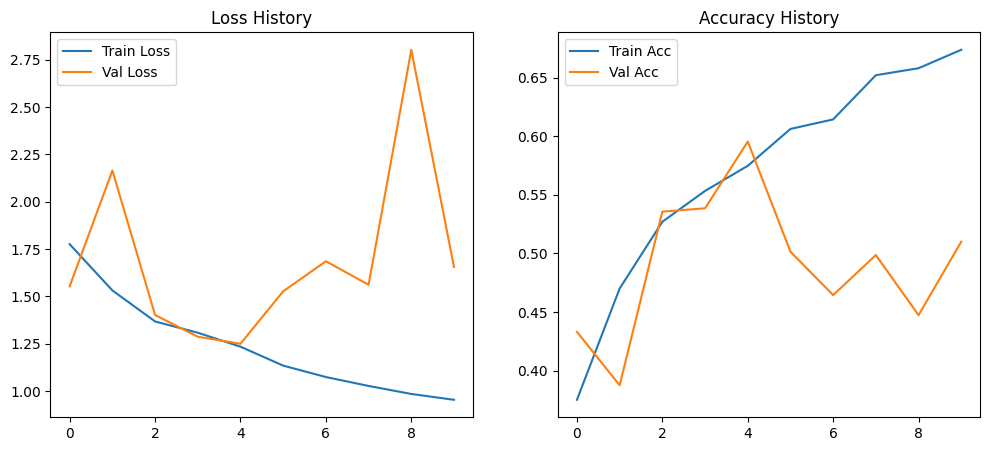

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy History')
plt.legend()
plt.show()